In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, calculateEcc, eccL2Distance, eccWassersteinDistance, IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH

In [2]:
def generateVPWaveletKernel():
    n=3
    nodes = np.cos(np.pi * np.arange(1, 2*n, 2) / (2*n))
    vp2d = np.outer(nodes, nodes)
    vp2d = vp2d - vp2d.mean()
    vp2d = vp2d / np.max(np.abs(vp2d))
    return vp2d.astype(np.float32)
vp = generateVPWaveletKernel()   

In [3]:
kernels = loadKernels(CSVPATH)

In [4]:
magVp  = computeMagnitudeResponse(vp)
magRob = computeMagnitudeResponse(kernels[IDXROBUST])
magVul = computeMagnitudeResponse(kernels[IDXVULNERABLE])

t, eccVp  = calculateEcc(magVp)
_, eccRob = calculateEcc(magRob)
_, eccVul = calculateEcc(magVul)

dL2Rob = eccL2Distance(eccRob, eccVp)
dL2Vul = eccL2Distance(eccVul, eccVp)
dWRob  = eccWassersteinDistance(eccRob, eccVp)
dWVul  = eccWassersteinDistance(eccVul, eccVp)

print(f"Kernel {IDXROBUST}  (Most Robust)     L2={dL2Rob:.4f}  Wasserstein={dWRob:.4f}")
print(f"Kernel {IDXVULNERABLE} (Most Vulnerable)  L2={dL2Vul:.4f}  Wasserstein={dWVul:.4f}")


Kernel 42  (Most Robust)     L2=24.5764  Wasserstein=5.1063
Kernel 806 (Most Vulnerable)  L2=33.6749  Wasserstein=9.6095


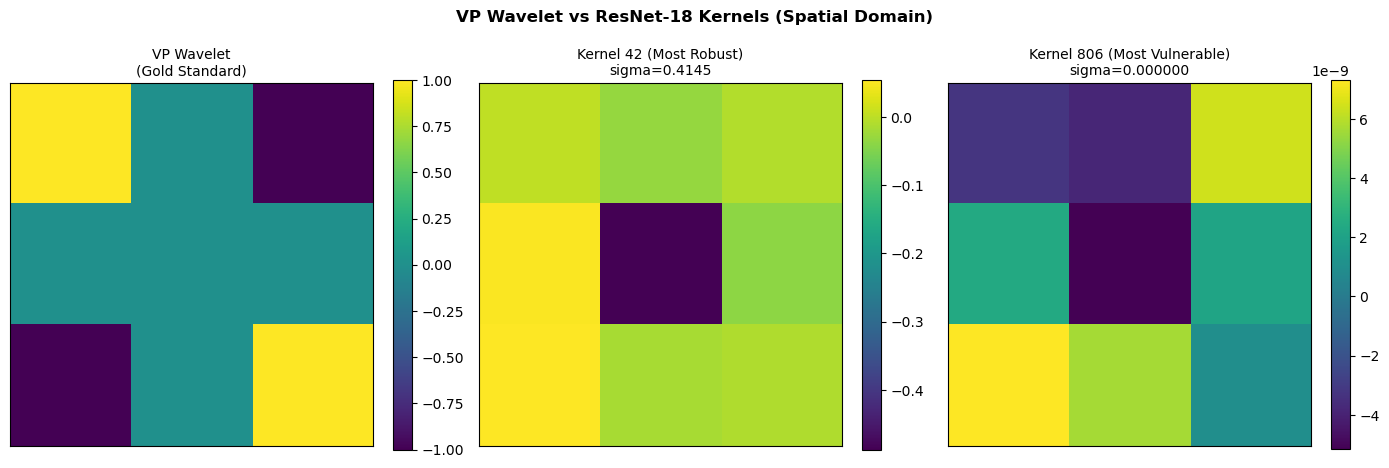

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("VP Wavelet vs ResNet-18 Kernels (Spatial Domain)",
             fontsize=12, fontweight='bold')
for ax, k, title in zip(axes,
                         [vp, kernels[IDXROBUST], kernels[IDXVULNERABLE]],
                         ["VP Wavelet\n(Gold Standard)",
                          f"Kernel {IDXROBUST} (Most Robust)\nsigma={computeSigma(kernels[IDXROBUST]):.4f}",
                          f"Kernel {IDXVULNERABLE} (Most Vulnerable)\nsigma={computeSigma(kernels[IDXVULNERABLE]):.6f}"]):
    im = ax.imshow(k, cmap='viridis')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("VPSpatialComparison.png", dpi=150, bbox_inches='tight')
plt.show()

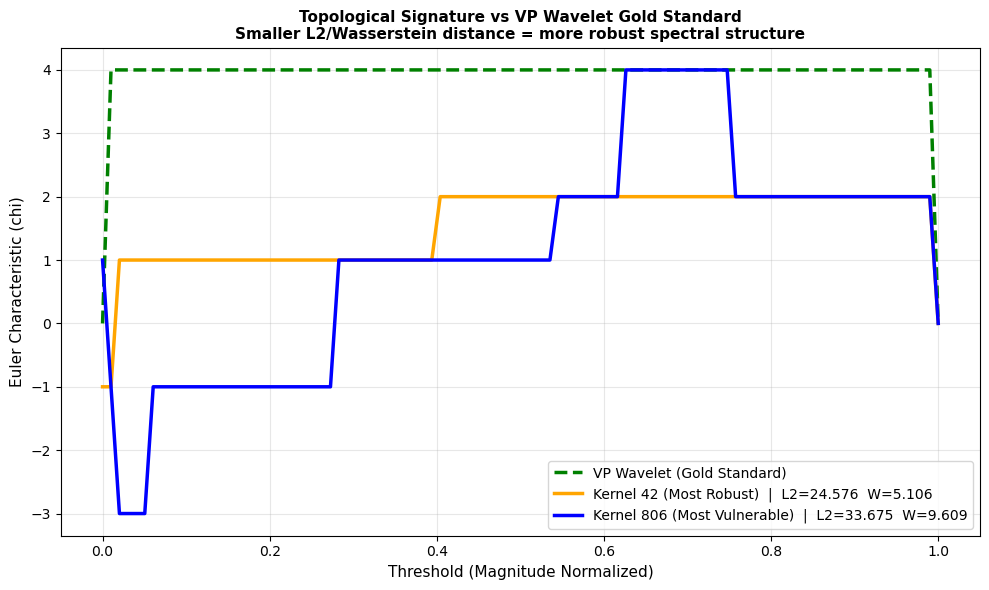

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, eccVp,  color='green',  linewidth=2.5, linestyle='--',
        label='VP Wavelet (Gold Standard)')
ax.plot(t, eccRob, color='orange', linewidth=2.5,
        label=f'Kernel {IDXROBUST} (Most Robust)  |  L2={dL2Rob:.3f}  W={dWRob:.3f}')
ax.plot(t, eccVul, color='blue',   linewidth=2.5,
        label=f'Kernel {IDXVULNERABLE} (Most Vulnerable)  |  L2={dL2Vul:.3f}  W={dWVul:.3f}')
ax.set_title("Topological Signature vs VP Wavelet Gold Standard\n"
             "Smaller L2/Wasserstein distance = more robust spectral structure",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Threshold (Magnitude Normalized)", fontsize=11)
ax.set_ylabel("Euler Characteristic (chi)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("VPEccComparison.png", dpi=150, bbox_inches='tight')
plt.show()

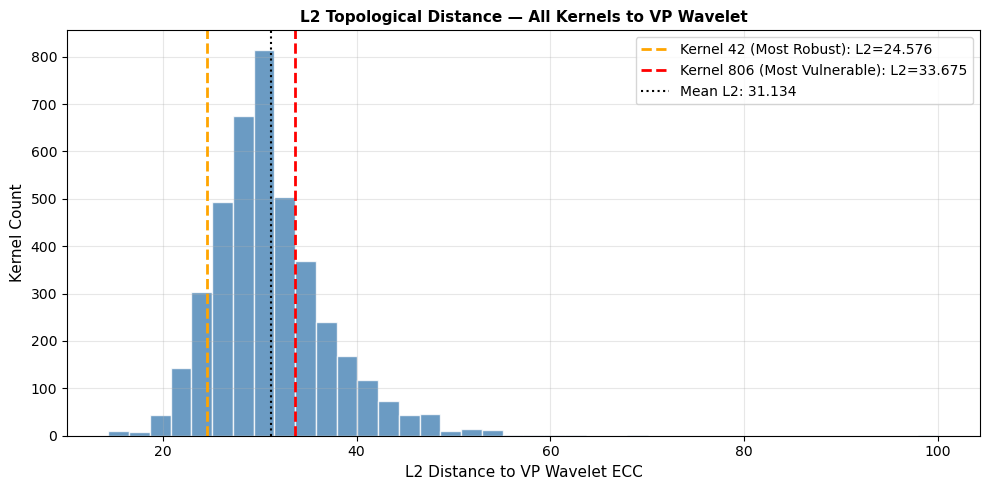

In [7]:
allL2 = []
for h in kernels:
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    allL2.append(eccL2Distance(ecc, eccVp))
allL2 = np.array(allL2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(allL2, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(allL2[IDXROBUST],     color='orange', linewidth=2, linestyle='--',
           label=f'Kernel {IDXROBUST} (Most Robust): L2={allL2[IDXROBUST]:.3f}')
ax.axvline(allL2[IDXVULNERABLE], color='red',    linewidth=2, linestyle='--',
           label=f'Kernel {IDXVULNERABLE} (Most Vulnerable): L2={allL2[IDXVULNERABLE]:.3f}')
ax.axvline(np.mean(allL2),        color='black',  linewidth=1.5, linestyle=':',
           label=f'Mean L2: {np.mean(allL2):.3f}')
ax.set_title("L2 Topological Distance — All Kernels to VP Wavelet",
             fontsize=11, fontweight='bold')
ax.set_xlabel("L2 Distance to VP Wavelet ECC", fontsize=11)
ax.set_ylabel("Kernel Count", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("VPDistanceDistribution.png", dpi=150, bbox_inches='tight')
plt.show()